# <center>Metody Numeryczne</center>

# Laboratorium 6: Iteracyjne równania liniowe i macierze rzadkie


**Wykonał:** \<imię i nazwisko\>

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**

Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania układów równań liniowych w postaci macierzowej, w szczególności z wykorzystaniem rzadkich macierzy prostokątnych.


Dana jest prostokątna, [rzadka](https://en.wikipedia.org/wiki/Sparse_matrix) macierz $\mathbf{A}$ o wymiarach $m \times n$ oraz wektor kolumnowy $\mathbf{b}$ o wymiarach $m \times 1$. Należy rozwiązać układ równań postaci:
 
$$
\mathbf{Ax}=\mathbf{b}
$$
  
gdzie:
- $\mathbf{A}$ - macierz współczynników z lewej strony równania, 
- $\mathbf{x}$ - wektor kolumnowy zmiennych,
- $\mathbf{b}$ - wektor kolumnowy wyników prawej strony równania. 

Do oceny jakości rozwiązania wykorzystywać będziemy residuum (ang. *residual*):

$$
\mathbf{r}=\mathbf{b}-\mathbf{Ax}
$$


### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`.

---

In [118]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time

---

### **Zadanie 1.**

W macierzach rzadkich większość elementów jest zerami, więc przechowywanie całych macierzy w pamięci jest nieefektywne. W celu optymalizacji macierze te zapisuje się w przeznaczonych do tego [formatach przechowywania danych](https://docs.scipy.org/doc/scipy/reference/sparse.html#usage-information), jakie udostępnia m.in. moduł [`scipy.sparse`](https://docs.scipy.org/doc/scipy/reference/sparse.html). W ramach laboratorium korzystać będziemy z formatu [Compressed Sparse Column (CSC)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csc_array.html).

1. Zapoznaj się z różnymi formatami przechowywania macierzy rzadkich w pamięci.

2. Dla $10$ równo rozmieszczonych wartości $m$ z zakresu $[100, 10000]$ wygeneruj macierze rzadkie wymiaru $m \times m$ używając [`sp.sparse.random_array()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.random_array.html) z parametrem `density=0.01` oraz parametrem `format` ustawionym tak, aby wygenerowane macierze zapisane zostały w formacie CSC.

2. Porównaj ile pamięci zajmują te same macierze zapisane w formacie `numpy.ndarray` oraz w formacie `scipy.sparse.csc_array`. W tym celu przekonwertuj kopie macierzy utworzonych w poprzednim punkcie do formatu `numpy.ndarray` używając odpowiedniej metody z modułu `scipy.sparse`. Wynik zaprezentuj na jednym wykresie typu *scatter plot*.

3. Opisz wnioski wynikające z wykresu.

> **Wskazówka:** Do obliczenia rozmiaru zmiennych skorzystaj z fragmentu kodu podanego poniżej.


[  100  1200  2300  3400  4500  5600  6700  7800  8900 10000]


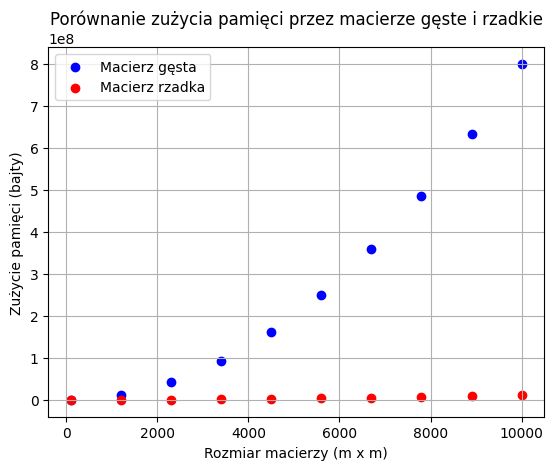

In [119]:
# Fragment kodu wyznaczający ilość zużycia pamięci przez macierze (w bajtach).
m: np.ndarray = np.linspace(100, 10000, 10, dtype=int)
mem_n = []
mem_s = []
print(m)
for i in m:
    s: sp.sparse.csc_array = sp.sparse.random_array((i, i), density=0.01, format='csc', dtype=np.float64)
    n = s.toarray()
    s_memory_size = s.data.nbytes + s.indices.nbytes + s.indptr.nbytes
    n_memory_size = n.nbytes
    #print(n)
    #print(s)
    #print(f"Rozmiar macierzy rzadkiej: {s_memory_size} bajtów")
    mem_n.append(n_memory_size)
    mem_s.append(s_memory_size)
plt.scatter(m, mem_n, label='Macierz gęsta', color='blue')
plt.scatter(m, mem_s, label='Macierz rzadka', color='red')
plt.xlabel('Rozmiar macierzy (m x m)')
plt.ylabel('Zużycie pamięci (bajty)')
plt.title('Porównanie zużycia pamięci przez macierze gęste i rzadkie')
plt.legend()
plt.grid()
plt.show()

---

### **Zadanie 2.**

Korzystając z wiedzy zdobytej podczas realizacji **Zadania 1.** wykonaj polecenia.

1. Wygeneruj macierze rzadkie $\mathbf{A}$ i $\mathbf{B}$ o wymiarach $1000 \times 1000$. Zapisz je w formatach `scipy.sparse.csc_array` oraz `numpy.ndarray`.

2. Porównaj czas potrzebny na wykonanie mnożenia macierzowego $\mathbf{AB}$ dla macierzy zapisanych w formacie `numpy.ndarray` oraz `scipy.sparse.csc_array`.

3. Opisz z czego wynika różnica.

In [145]:
A_csc = sp.sparse.random_array((1000, 1000), density=0.01, format='csc', dtype=np.float64)
B_csc = sp.sparse.random_array((1000, 1000), density=0.01, format='csc', dtype=np.float64)
A_dense = A_csc.toarray()
B_dense = B_csc.toarray()

start = time.perf_counter()
C_csc = A_csc @ B_csc
end = time.perf_counter()
print(f"Czas mnożenia macierzy rzadkich: {end - start:.6f} sekund")

start = time.perf_counter()
C_dense = A_dense @ B_dense
end = time.perf_counter()
print(f"Czas mnożenia macierzy gęstych: {end - start:.6f} sekund")


#Wyniki pokazują, że mnożenie macierzy rzadkich jest znacznie szybsze niż mnożenie macierzy gęstych, 
#zwłaszcza przy dużych rozmiarach macierzy. Dzieje się tak dlatego, że macierze rzadkie przechowują tylko niezerowe elementy, 
#co zmniejsza ilość operacji potrzebnych do wykonania mnożenia.


Czas mnożenia macierzy rzadkich: 0.001332 sekund
Czas mnożenia macierzy gęstych: 0.019216 sekund


---

### **Zadanie 3.**

Aby metody iteracyjne znalazły rozwiązanie układu równań $\mathbf{Ax}=\mathbf{b}$ należy zadbać o to aby macierz $\mathbf{A}$ była [diagonalnie zdominowana](https://en.wikipedia.org/wiki/Diagonally_dominant_matrix). Przekształcenie dowolnej macierzy do tej postaci jest skomplikowanym zagadnieniem, które nie będzie poruszane w ramach tego laboratorium. Na potrzeby zadania należy jedynie sprawdzić czy używana macierz posiada tę własność.

**Punkt 1.**

Zaimplementuj funkcję *`is_diagonally_dominant()`* sprawdzającą czy macierz jest diagonalnie zdominowana.

> **Wskazówka:** W implementacji nie należy używać pętli *for*, ponieważ biblioteka NumPy zawiera funkcje, które znacznie wydajniej iterują po elementach tablic typu `numpy.ndarray`. Lepiej skorzystać z funkcji [`np.sum()`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) oraz [`np.diagonal()`](https://numpy.org/doc/stable/reference/generated/numpy.diagonal.html).

<br>

**Punkt 2.**

Poniżej znajduje się zaimplementowana funkcja `generate_matrix()`. Przy jej pomocy wygeneruj macierz $\mathbf{A}$ o wymiarach $1000 \times 1000$. Następnie zweryfikuj czy wygenerowana macierz jest diagonalnie zdominowana. Wygeneruj również wektor wartości losowych $\mathbf{b}$ o długości $1000$.

<br>

**Punkt 3.**

Istnieje wiele metod iteracyjnego rozwiązywania równań, natomiast nie różnią się one znacząco od siebie w kwestii wywołania metody, dlatego w dalszej części zadania należy wybrać jedną z metod: [GMRES](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.gmres.html) lub [Conjugate Gradient](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html) i dla niej przeprowadzić dalszą analizę. 

1. Korzystając z funkcji *`residual_norm()`*, oraz macierzy zdefiniowanych w **Punkcie 2.**, zbadaj wpływ argumentów `rtol` i `maxiter` na działanie wybranej metody. Sporządź wykresy przedstawiające wartość normy residuum w zależności od zmiany podanych parametrów.

2. Opisz zaobserwowane zależności.

>**Wskazówka:** Metoda *Conjugate Gradient* wymaga aby macierz była dodatnio określona. Można to zapewnić poprzez podanie argumentu `is_symmetric=True` do funkcji `generate_matrix()`.


In [146]:
# Implementacja funkcji generate_matrix().

from scipy.sparse import diags_array, csc_array


def generate_matrix(m: int = 1000, is_symmetric: bool = False) -> csc_array:
    """Funkcja generująca rzadką, diagonalnie zdominowaną macierz rozmiaru m x m.

    Parameters:
        m (int): Wymiar macierzy.
        is_symmetric (bool): Czy macierz ma być symetryczna.

    Returns:
        (scipy.sparse.csc_array): Macierz rzadka, diagonalnie zdominowana (m,m).

    Raises:
        TypeError: Jeśli 'm' nie jest liczbą całkowitą lub 'is_symmetric' nie 
            jest wartością logiczną.
        ValueError: Jeśli 'm' jest mniejsze niż 5.
    """
    if not isinstance(m, int):
        raise TypeError(
            f"Argument 'm' musi być liczbą całkowitą, otrzymano: {type(m).__name__}."
        )
    if not isinstance(is_symmetric, bool):
        raise TypeError(
            f"Argument 'is_symmetric' musi być wartością logiczną, otrzymano: {type(is_symmetric).__name__}."
        )
    if m < 5:
        raise ValueError("Argument 'm' musi być większy lub równy 5.")

    if is_symmetric:
        num_upper_diags = np.random.randint(2, m // 2)
        diagonal_values = np.random.rand(num_upper_diags)
        matrix = diags_array(
            diagonal_values, offsets=np.arange(1, num_upper_diags + 1), shape=(m, m)
        )
        matrix = matrix + matrix.T
    else:
        num_upper_diags = np.random.randint(2, m // 2)
        num_lower_diags = np.random.randint(2, m // 2)
        diagonal_values = np.random.rand(num_upper_diags + num_lower_diags)
        matrix = diags_array(
            diagonal_values,
            offsets=np.arange(-num_lower_diags, num_upper_diags),
            shape=(m, m),
        )

    row_sums = np.asarray(matrix.sum(axis=1)).flatten()
    diagonal_vals = row_sums - np.abs(matrix.diagonal()) + np.random.rand(m)
    matrix.setdiag(diagonal_vals)

    return matrix.tocsc()

In [148]:
#1.
def is_diagonally_dominant(A: np.ndarray | sp.sparse.csc_array) -> bool | None:
    if not isinstance(A, (np.ndarray, sp.sparse.csc_array)):
        return None
    if not (A.ndim == 2):
        return None
    (m, n) = A.shape
    if m != n:
        return None
    

    for i in range(m):
        suma = 0.0
        for j in range(n):
            if i != j:
                suma += abs(A[i, j])
        if abs(A[i, i]) <= suma:
            return False
    return True

#3.
def residual_norm(A: np.ndarray, x: np.ndarray, b: np.ndarray) -> float | None:
    if not (isinstance(A, np.ndarray) and isinstance(x, np.ndarray) and isinstance(b, np.ndarray)):
        return None
    if not (A.ndim == 2 and x.ndim == 1 and b.ndim == 1):
        return None
    (m, n) = A.shape
    if x.shape[0] != n or b.shape[0] != m:
        return None
    r = b - A.dot(x)
    return np.linalg.norm(r)

A = generate_matrix()
print(A)
print(is_diagonally_dominant(A))


<Compressed Sparse Column sparse array of dtype 'float64'
	with 465031 stored elements and shape (1000, 1000)>
  Coords	Values
  (427, 0)	0.5356307995731493
  (426, 0)	0.1473133007531734
  (425, 0)	0.7675812852577927
  (424, 0)	0.4583862737626109
  (423, 0)	0.15800883060435367
  (422, 0)	0.35415345509229246
  (421, 0)	0.5961463415680107
  (420, 0)	0.05774170456018035
  (419, 0)	0.3468946602232642
  (418, 0)	0.11655520178213152
  (417, 0)	0.17279067029552764
  (416, 0)	0.9296193218526675
  (415, 0)	0.38268469355787904
  (414, 0)	0.4669801443055912
  (413, 0)	0.17518768845306365
  (412, 0)	0.1755834399749936
  (411, 0)	0.10729603462753856
  (410, 0)	0.15104609257638146
  (409, 0)	0.9687925310943606
  (408, 0)	0.8544079537787007
  (407, 0)	0.9225758224733268
  (406, 0)	0.7199280365453509
  (405, 0)	0.06853069749880236
  (404, 0)	0.9180925520344579
  (403, 0)	0.01258621260778614
  :	:
  (885, 999)	0.7985442272201819
  (884, 999)	0.5975135284342229
  (883, 999)	0.07202592635632421
  (882, 9

---

**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)